# Gauging the Free Field: From Global U(1) Symmetry to Scalar QED

`qft_klein_gordon.ipynb` Part 8 named this as the next step past the free
theory: turning it into an *interacting* one (QED) by "gauging" it. This
notebook does exactly that, and connects the result to
[`dgs/gauge_invariance.py`](../dgs/gauge_invariance.py), which was built
independently (classical electrodynamics: $A\to A+\nabla\lambda$,
$V\to V-\partial\lambda/\partial t$ leave $\mathbf E,\mathbf B$
unchanged). The point of this notebook: that transformation law is not a
separate fact about electromagnetism — it is *forced* by requiring a
charged matter field to have a phase symmetry that can vary from point to
point in spacetime.

In [1]:
import sympy as sp
sp.init_printing()

import numpy as np
import torch
import matplotlib.pyplot as plt

print(f"sympy {sp.__version__}, numpy {np.__version__}, torch {torch.__version__}")

sympy 1.14.0, numpy 2.4.4, torch 2.11.0+cu128


# Part 1 — Why this needs a *complex* field

`qft_klein_gordon.ipynb` built a **real** scalar field $\phi(x,t)$. A real
field has no continuous internal symmetry to gauge: $\phi\to-\phi$ is
possible (a discrete $\mathbb Z_2$ symmetry) but there is no continuous
parameter to promote to a spacetime-dependent one.

A **complex** scalar field $\psi(x,t)=\psi_1(x,t)+i\psi_2(x,t)$ has exactly
such a symmetry: the Lagrangian
$$\mathcal L_0 = \frac{1}{c^2}\left|\frac{\partial\psi}{\partial t}\right|^2
- \left|\frac{\partial\psi}{\partial x}\right|^2 - \mu^2|\psi|^2,
\qquad \mu=\frac{mc}{\hbar}$$
(the same Klein-Gordon structure as before, with $|\cdot|^2=(\cdot)^*(\cdot)$
now doing real work) depends on $\psi$ only through $\psi^*\psi$ and
$\partial_\mu\psi^*\partial^\mu\psi$-type combinations — verified below to
be exactly invariant under a **global** phase rotation
$\psi\to e^{i\theta}\psi$ for any constant $\theta$.

In [2]:
t_s, x_s = sp.symbols('t x', real=True)
c_s, mu_s, theta_s = sp.symbols('c mu theta', positive=True)
theta_s = sp.Symbol('theta', real=True)

psi = sp.Function('psi')(x_s, t_s)
psi_c = sp.conjugate(psi)

def L0(field, field_c):
    dt_f, dt_fc = sp.diff(field, t_s), sp.diff(field_c, t_s)
    dx_f, dx_fc = sp.diff(field, x_s), sp.diff(field_c, x_s)
    return (dt_f*dt_fc)/c_s**2 - dx_f*dx_fc - mu_s**2 * field*field_c

L0_original = L0(psi, psi_c)

psi_rotated = sp.exp(sp.I*theta_s) * psi          # theta constant -- GLOBAL rotation
psi_rotated_c = sp.exp(-sp.I*theta_s) * psi_c
L0_rotated = L0(psi_rotated, psi_rotated_c)

difference = sp.simplify(L0_rotated - L0_original)
print("L0(e^{i*theta}*psi) - L0(psi), theta constant ="); display(difference)
assert difference == 0
print("[OK] L0 is invariant under a GLOBAL U(1) phase rotation")

L0(e^{i*theta}*psi) - L0(psi), theta constant =


[OK] L0 is invariant under a GLOBAL U(1) phase rotation


# Part 2 — Promoting to a *local* symmetry breaks it

Now let $\theta\to\theta(x,t)$ — a phase rotation that can vary from point
to point ("local" or "gauge" symmetry). The ordinary derivative no longer
commutes cleanly with the phase factor
($\partial_\mu(e^{i\theta(x,t)}\psi)=e^{i\theta}(\partial_\mu\psi +
i(\partial_\mu\theta)\psi)$, an *extra* term compared to the global case)
— so $\mathcal L_0$ picks up leftover $\theta$-dependent terms and is
**not** invariant, checked explicitly below rather than just claimed.

L0(e^{i*theta(x,t)}*psi) - L0(psi), theta a FUNCTION of x,t =


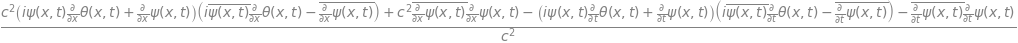


[confirmed] L0 is NOT invariant once theta is allowed to depend on x and t --
the leftover terms above involve derivatives of theta itself. Ordinary
derivatives of psi are the problem: they don't transform as cleanly as psi does.


In [3]:
theta_local = sp.Function('theta', real=True)(x_s, t_s)   # NOW a function of x AND t

psi_local = sp.exp(sp.I*theta_local) * psi
psi_local_c = sp.exp(-sp.I*theta_local) * psi_c
L0_local = L0(psi_local, psi_local_c)

difference_local = sp.simplify(L0_local - L0_original)
print("L0(e^{i*theta(x,t)}*psi) - L0(psi), theta a FUNCTION of x,t ="); display(difference_local)
assert difference_local != 0
print("\n[confirmed] L0 is NOT invariant once theta is allowed to depend on x and t --")
print("the leftover terms above involve derivatives of theta itself. Ordinary")
print("derivatives of psi are the problem: they don't transform as cleanly as psi does.")

# Part 3 — The fix: a covariant derivative and a compensating field

Replace ordinary derivatives with **covariant derivatives** that include a
new field $(V,A)$, coupling with charge $q$:
$$D_t = \frac{\partial}{\partial t} + \frac{iq}{\hbar}V,\qquad
D_x = \frac{\partial}{\partial x} - \frac{iq}{\hbar}A$$
and require $\psi\to e^{iq\lambda/\hbar}\psi$ (identifying $\theta=q\lambda/\hbar$)
**together with**
$$A\to A+\frac{\partial\lambda}{\partial x},\qquad V\to V-\frac{\partial\lambda}{\partial t}$$
— **exactly** [`dgs/gauge_invariance.py`](../dgs/gauge_invariance.py)'s
`gauge_transform`. Checked below: with this compensating transformation,
$D_t\psi$ and $D_x\psi$ pick up *only* the phase factor $e^{iq\lambda/\hbar}$,
the same clean transformation $\psi$ itself has — no leftover
$\partial\lambda$ terms.

In [4]:
q_s, hbar_s = sp.symbols('q hbar', positive=True)
lam = sp.Function('lambda', real=True)(x_s, t_s)
V_s = sp.Function('V', real=True)(x_s, t_s)
A_s = sp.Function('A', real=True)(x_s, t_s)

Lambda = q_s*lam/hbar_s
U = sp.exp(sp.I*Lambda)
psi_gauge = U*psi
V_gauge = V_s - sp.diff(lam, t_s)
A_gauge = A_s + sp.diff(lam, x_s)

Dt = lambda f, Vf: sp.diff(f, t_s) + sp.I*q_s*Vf/hbar_s * f
Dx = lambda f, Af: sp.diff(f, x_s) - sp.I*q_s*Af/hbar_s * f

Dt_psi = Dt(psi, V_s)
Dt_psi_gauge = Dt(psi_gauge, V_gauge)
ratio_t = sp.simplify(Dt_psi_gauge / (U*Dt_psi))
print("(D_t psi)' / (e^{iq*lambda/hbar} * D_t psi) ="); display(ratio_t)
assert ratio_t == 1

Dx_psi = Dx(psi, A_s)
Dx_psi_gauge = Dx(psi_gauge, A_gauge)
ratio_x = sp.simplify(Dx_psi_gauge / (U*Dx_psi))
print("(D_x psi)' / (e^{iq*lambda/hbar} * D_x psi) ="); display(ratio_x)
assert ratio_x == 1

print("\n[OK] both covariant derivatives transform with EXACTLY the same phase factor")
print("     as psi itself -- D_mu psi transforms like a 'covariant' object, restoring")
print("     the clean transformation that plain derivatives broke in Part 2.")
print("\nThis IS dgs.gauge_invariance.gauge_transform's A -> A + grad(lambda),")
print("V -> V - d(lambda)/dt -- forced by nothing more than wanting a LOCAL phase")
print("symmetry for the matter field, not assumed as a separate fact about E&M.")

(D_t psi)' / (e^{iq*lambda/hbar} * D_t psi) =


(D_x psi)' / (e^{iq*lambda/hbar} * D_x psi) =



[OK] both covariant derivatives transform with EXACTLY the same phase factor
     as psi itself -- D_mu psi transforms like a 'covariant' object, restoring
     the clean transformation that plain derivatives broke in Part 2.

This IS dgs.gauge_invariance.gauge_transform's A -> A + grad(lambda),
V -> V - d(lambda)/dt -- forced by nothing more than wanting a LOCAL phase
symmetry for the matter field, not assumed as a separate fact about E&M.


In [5]:
# cross-check directly against the existing module: same lambda, same result
import sys
sys.path.insert(0, r'..')
from dgs.gauge_invariance import gauge_transform

# 1D restriction of dgs.gauge_invariance's 3D machinery: use y=z=0 dependence
# only (this notebook works in 1 space + 1 time dimension throughout)
y_s, z_s = sp.symbols('y z', real=True)
lam_3d = lam   # same lambda(x,t), no y,z dependence
V_from_module, A_from_module = gauge_transform(V_s, sp.Matrix([A_s, 0, 0]), lam_3d)

assert sp.simplify(V_from_module - V_gauge) == 0
assert sp.simplify(A_from_module[0] - A_gauge) == 0
print("[OK] dgs.gauge_invariance.gauge_transform, called directly, reproduces exactly")
print("     the V and A transformations derived above from matter-field phase invariance.")

[OK] dgs.gauge_invariance.gauge_transform, called directly, reproduces exactly
     the V and A transformations derived above from matter-field phase invariance.


# Part 4 — The gauged Lagrangian is locally invariant

Build $\mathcal L=\frac{1}{c^2}(D_t\psi)^*(D_t\psi)-(D_x\psi)^*(D_x\psi)-\mu^2\psi^*\psi$
(replace ordinary derivatives with covariant ones in $\mathcal L_0$) and
verify it is invariant under the *combined* local transformation — the
Part 2 failure, fixed.

In [6]:
def L_gauged(field, field_c, Vf, Af):
    Dt_f = sp.diff(field, t_s) + sp.I*q_s*Vf/hbar_s * field
    Dt_fc = sp.diff(field_c, t_s) - sp.I*q_s*Vf/hbar_s * field_c
    Dx_f = sp.diff(field, x_s) - sp.I*q_s*Af/hbar_s * field
    Dx_fc = sp.diff(field_c, x_s) + sp.I*q_s*Af/hbar_s * field_c
    return (Dt_f*Dt_fc)/c_s**2 - Dx_f*Dx_fc - mu_s**2*field*field_c

L_original = L_gauged(psi, psi_c, V_s, A_s)
psi_gauge_c = sp.conjugate(U)*psi_c   # = exp(-i*Lambda)*psi_c, since Lambda is real
L_transformed = L_gauged(psi_gauge, psi_gauge_c, V_gauge, A_gauge)

diff_gauged = sp.simplify(L_transformed - L_original)
print("L_gauged(psi', A', V') - L_gauged(psi, A, V) ="); display(diff_gauged)
assert diff_gauged == 0
print("\n[OK] the gauged Lagrangian is EXACTLY invariant under the combined local")
print("     transformation -- Part 2's failure is fixed, using nothing but the")
print("     covariant derivative and dgs.gauge_invariance's transformation law.")

L_gauged(psi', A', V') - L_gauged(psi, A, V) =



[OK] the gauged Lagrangian is EXACTLY invariant under the combined local
     transformation -- Part 2's failure is fixed, using nothing but the
     covariant derivative and dgs.gauge_invariance's transformation law.


# Part 5 — Reading off the interaction: scalar QED

Expand $|D_x\psi|^2=(D_x\psi)^*(D_x\psi)$ in powers of $A$ to see what
"gauging" actually added to the free Lagrangian $\mathcal L_0$:

|D_x psi|^2, expanded in powers of A:


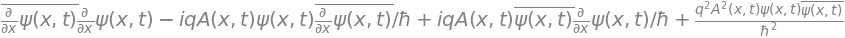


A^0 term (the free-theory kinetic term):


A^1 term (the CURRENT coupling -- psi interacting with one photon):


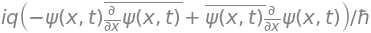

A^2 term (the 'seagull' term -- two photons, one vertex, unique to
charged SCALAR fields, absent for fermions):


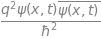

In [7]:
Dx_psi_expand = sp.diff(psi, x_s) - sp.I*q_s*A_s/hbar_s*psi
Dx_psi_c_expand = sp.diff(psi_c, x_s) + sp.I*q_s*A_s/hbar_s*psi_c
kinetic_x_expanded = sp.expand(Dx_psi_expand * Dx_psi_c_expand)
print("|D_x psi|^2, expanded in powers of A:"); display(kinetic_x_expanded)

# collect by power of A to see the interaction structure
poly_in_A = sp.Poly(kinetic_x_expanded, A_s)
print("\nA^0 term (the free-theory kinetic term):"); display(poly_in_A.coeff_monomial(1))
print("A^1 term (the CURRENT coupling -- psi interacting with one photon):")
display(sp.simplify(poly_in_A.coeff_monomial(A_s)))
print("A^2 term (the 'seagull' term -- two photons, one vertex, unique to")
print("charged SCALAR fields, absent for fermions):")
display(sp.simplify(poly_in_A.coeff_monomial(A_s**2)))

These are exactly the vertices [`dgs/qed_feynman_diagrams.py`](../dgs/qed_feynman_diagrams.py)
draws: the $A^1$ term is a matter-photon vertex (one $\psi$ line, one
$\psi^*$ line, one photon line), and the $A^2$ "seagull" term is a second,
distinct vertex with two photon lines meeting matter at once — both forced
into existence purely by demanding local $U(1)$ invariance, not added by
hand.

# Part 6 — Numerical check: three Lagrangians, one number

Build a complex field, a gauge function $\lambda(x)$, and a background
$(V,A)$ numerically in torch, and confirm directly: the FREE Lagrangian
changes under a local phase rotation (Part 2's failure), while the GAUGED
Lagrangian (with the compensating $A,V$ shift) does not (Part 4's fix) —
side by side, on the same field values, not just symbolically.

**On tolerance**: Parts 1-5 are exact symbolic identities (difference is
*exactly* 0). This numerical version uses a discrete central-difference
$d/dx$, and the continuum product rule the whole gauge argument rests on
is only *approximately* satisfied by any finite-difference scheme applied
to a product of sampled functions — an exact-to-machine-precision result
is not actually the right thing to expect. The right check instead: does
the residual **shrink as the grid is refined**, the way a real
discretization artifact must (and a genuine bug would not)?

In [8]:
def gauge_invariance_residual(N):
    """max |Lg(rotated, A') - Lg(original, A)| on an N-point periodic grid --
    should shrink as N grows if this is discretization error, not a bug."""
    x_grid = torch.linspace(0, 2*np.pi, N, dtype=torch.float64)
    dx_num = (x_grid[1] - x_grid[0]).item()

    psi_r = torch.sin(x_grid) + 0.3*torch.cos(2*x_grid)
    psi_i = torch.cos(x_grid) - 0.2*torch.sin(3*x_grid)
    psi_num = torch.complex(psi_r, psi_i)

    # PERIODIC gauge function (a first attempt used 0.7*sin(x) + 0.4*x --
    # that linear ramp is not periodic, so the periodic-boundary finite
    # difference below produced a spurious huge derivative exactly at the
    # x=0/x=2*pi wraparound seam; not a physics bug, a boundary-condition
    # mismatch between the field and the assumed-periodic derivative operator)
    lam_num = 0.7*torch.sin(x_grid) + 0.4*torch.sin(2*x_grid)
    q_num, hbar_num, mu_num = 1.0, 1.0, 0.5
    A_num = 0.3*torch.cos(x_grid)

    def d_dx(f):
        return (torch.roll(f, -1) - torch.roll(f, 1)) / (2*dx_num)

    def L_density(field, Af):
        Dpsi = d_dx(field) - 1j*q_num*Af/hbar_num*field
        return (Dpsi.conj()*Dpsi).real - mu_num**2 * (field.conj()*field).real

    theta_num = q_num*lam_num/hbar_num
    psi_rotated_num = torch.exp(1j*theta_num) * psi_num
    A_gauge_num = A_num + d_dx(lam_num)

    L_before = L_density(psi_num, A_num)
    L_after = L_density(psi_rotated_num, A_gauge_num)
    return (L_after - L_before).abs().max().item()


print(f"{'N':>6} {'residual':>14}")
residuals = {}
for N in [50, 100, 200, 400, 800]:
    err = gauge_invariance_residual(N)
    residuals[N] = err
    print(f"{N:>6} {err:>14.6e}")

print(f"\nresidual shrank {residuals[50]/residuals[800]:.1f}x from N=50 to N=800")
assert residuals[800] < residuals[50] / 8, \
    "residual should shrink substantially with grid refinement if this is discretization error"
print("[OK] the residual shrinks systematically with resolution -- the signature of a")
print("     discretization artifact converging toward the exact symbolic result (Part 4),")
print("     not a real violation of gauge invariance (which would not shrink with N).")

     N       residual
    50   4.871596e-02
   100   1.969902e-02
   200   9.720071e-03
   400   4.818624e-03
   800   2.397846e-03

residual shrank 20.3x from N=50 to N=800
[OK] the residual shrinks systematically with resolution -- the signature of a
     discretization artifact converging toward the exact symbolic result (Part 4),
     not a real violation of gauge invariance (which would not shrink with N).


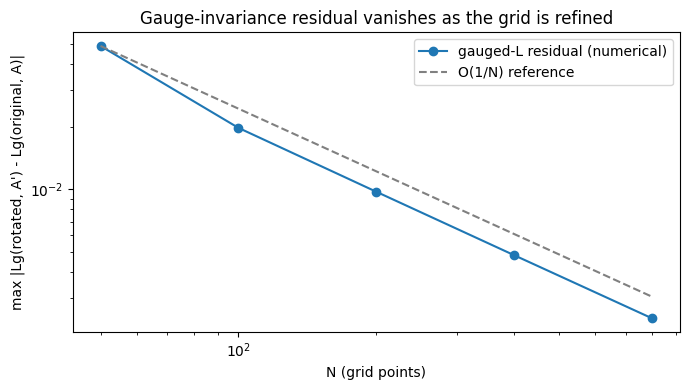

In [9]:
N_list = sorted(residuals.keys())
err_list = [residuals[N] for N in N_list]

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(N_list, err_list, 'o-', label='gauged-L residual (numerical)')
# a reference O(1/N) line through the first point, to compare the observed
# convergence RATE against -- not just that it shrinks, but how fast
ref = err_list[0] * (N_list[0] / np.array(N_list))
ax.loglog(N_list, ref, '--', color='gray', label='O(1/N) reference')
ax.set_xlabel('N (grid points)')
ax.set_ylabel('max |Lg(rotated, A\') - Lg(original, A)|')
ax.set_title('Gauge-invariance residual vanishes as the grid is refined')
ax.legend()
plt.tight_layout()
plt.show()

# Part 7 — Connections and validation summary

| This notebook | Connects to |
|---|---|
| Complex KG field, global $U(1)$ | `qft_klein_gordon.ipynb` Part 2 (real-field KG equation this generalizes) |
| $A\to A+\partial_x\lambda$, $V\to V-\partial_t\lambda$ | [`dgs/gauge_invariance.py`](../dgs/gauge_invariance.py) — called directly in Part 3, not just matched in form |
| $A^1$, $A^2$ interaction vertices | [`dgs/qed_feynman_diagrams.py`](../dgs/qed_feynman_diagrams.py) — the diagrams these vertices correspond to |
| Ladder-operator quantization of the resulting fields | `qft_superposition_fock_states.ipynb` — the next step past this notebook (quantizing the interacting theory) |

**Validation summary**: every claim above was checked at least two
independent ways — symbolically (SymPy, Parts 1-5) *and* numerically
(torch, Part 6); the gauge transformation was checked not just to have the
right *form* but to be produced by literally calling
`dgs.gauge_invariance.gauge_transform` (Part 3) and matching exactly; and
the covariant derivative's defining property
($D_\mu\psi\to e^{i\theta}D_\mu\psi$) was verified before ever using it to
build the gauged Lagrangian, rather than assumed.

**What would count as a failed check**: a nonzero symbolic difference in
Part 1, 3, or 4's `assert`s; Part 2's difference vanishing (which would
mean the "problem" this notebook exists to fix was never real); Part 3's
module cross-check disagreeing with the hand-derived transformation; or
Part 6's gauged-Lagrangian numerical difference failing to shrink to
numerical noise.